In [1]:
import QuantLib as ql

today = ql.Date(21, ql.September, 2021)
ql.Settings.instance().evaluationDate=today

Let’s say we have quoted prices for a set of bonds and we want to infer a discount curve from them. Each of the tuples below contains the start date, the maturity date, the coupon rate, and the quoted price for a bond. I’ll sort them by maturity; this is not required for fitting, but it will make it easier to plot the results. For simplicity, all bonds will have the same frequency, calendar and day-count convention, but that’s not a requirement; I might have added the extra information to the data.

In [4]:
data = [
    (ql.Date(1, 9, 2012), ql.Date(1, 9, 2049), 3.85, 150.41),
    (ql.Date(1, 9, 2018), ql.Date(1, 9, 2036), 2.25, 115.27),
    (ql.Date(15, 9, 2006), ql.Date(15, 9, 2041), 2.97, 160.42),
    (ql.Date(1, 9, 2017), ql.Date(1, 9, 2024), 3.75, 111.75),
    (ql.Date(1, 11, 2017), ql.Date(1, 11, 2022), 5.5, 106.91),
    (ql.Date(1, 12, 2008), ql.Date(1, 12, 2025), 2.0, 109.07),
    (ql.Date(1, 6, 2020), ql.Date(1, 6, 2027), 2.2, 111.63),
    (ql.Date(1, 8, 2018), ql.Date(1, 8, 2034), 5.0, 149.45),
    (ql.Date(1, 9, 2012), ql.Date(1, 9, 2046), 3.25, 135.1),
    (ql.Date(1, 9, 2015), ql.Date(1, 9, 2040), 5.0, 162.3),
    (ql.Date(1, 2, 2017), ql.Date(1, 2, 2037), 4.0, 140.85),
    (ql.Date(1, 3, 2021), ql.Date(1, 3, 2030), 3.5, 125.21),
    (ql.Date(1, 3, 2018), ql.Date(1, 3, 2040), 3.1, 128.9),
    (ql.Date(1, 3, 2008), ql.Date(1, 3, 2025), 5.0, 118.43),
    (ql.Date(1, 3, 2010), ql.Date(1, 3, 2047), 2.7, 123.23),
    (ql.Date(1, 6, 2020), ql.Date(1, 6, 2026), 1.6, 107.96),
    (ql.Date(1, 8, 2021), ql.Date(1, 8, 2023), 4.75, 109.65),
    (ql.Date(15, 5, 2021), ql.Date(15, 5, 2025), 1.45, 106.09),
    (ql.Date(1, 12, 2010), ql.Date(1, 12, 2028), 2.8, 117.3),
    (ql.Date(15, 7, 2013), ql.Date(15, 7, 2026), 2.1, 109.93),
    (ql.Date(1, 3, 2013), ql.Date(1, 3, 2048), 3.45, 140.06),
    (ql.Date(15, 9, 2015), ql.Date(15, 9, 2024), 2.53, 113.2),
    (ql.Date(1, 11, 2009), ql.Date(1, 11, 2026), 7.25, 137.49),
    (ql.Date(1, 4, 2016), ql.Date(1, 4, 2030), 1.35, 107.11),
    (ql.Date(1, 9, 2018), ql.Date(1, 9, 2044), 4.75, 163.84),
    (ql.Date(15, 5, 2021), ql.Date(15, 5, 2028), 1.39, 117.72),
    (ql.Date(1, 7, 2017), ql.Date(1, 7, 2024), 1.75, 105.96),
    (ql.Date(15, 9, 2012), ql.Date(15, 9, 2032), 1.33, 123.95),
    (ql.Date(1, 3, 2021), ql.Date(1, 3, 2032), 1.65, 109.41),
    (ql.Date(1, 3, 2020), ql.Date(1, 3, 2024), 4.5, 112.1),
    (ql.Date(15, 9, 2016), ql.Date(15, 9, 2026), 3.52, 124.85),
    (ql.Date(1, 11, 2018), ql.Date(1, 11, 2023), 9.0, 120.68),
    (ql.Date(1, 2, 2016), ql.Date(1, 2, 2028), 2.0, 111.43),
    (ql.Date(1, 8, 2017), ql.Date(1, 8, 2029), 3.0, 119.77),
    (ql.Date(1, 5, 2018), ql.Date(1, 5, 2031), 6.0, 151.21),
    (ql.Date(15, 9, 2017), ql.Date(15, 9, 2023), 3.18, 109.61),
    (ql.Date(15, 11, 2008), ql.Date(15, 11, 2024), 1.45, 105.51),
    (ql.Date(15, 9, 2013), ql.Date(15, 9, 2035), 3.01, 143.25),
    (ql.Date(1, 11, 2005), ql.Date(1, 11, 2027), 6.5, 138.74),
    (ql.Date(1, 8, 2009), ql.Date(1, 8, 2027), 2.05, 111.12),
    (ql.Date(1, 10, 2009), ql.Date(1, 10, 2023), 2.45, 106.02),
    (ql.Date(1, 9, 2019), ql.Date(1, 9, 2028), 4.75, 130.95),
    (ql.Date(1, 12, 2009), ql.Date(1, 12, 2026), 1.25, 106.28),
    (ql.Date(1, 9, 2014), ql.Date(1, 9, 2038), 2.95, 125.9),
    (ql.Date(1, 6, 2006), ql.Date(1, 6, 2025), 1.5, 105.91),
    (ql.Date(1, 3, 2009), ql.Date(1, 3, 2026), 4.5, 120.27),
    (ql.Date(1, 9, 2020), ql.Date(1, 9, 2033), 2.45, 117.91),
    (ql.Date(1, 8, 2007), ql.Date(1, 8, 2039), 5.0, 160.49),
    (ql.Date(15, 9, 2016), ql.Date(15, 9, 2022), 1.45, 102.15),
    (ql.Date(15, 5, 2017), ql.Date(15, 5, 2024), 1.85, 106.18),
    (ql.Date(1, 12, 2008), ql.Date(1, 12, 2024), 2.5, 109.19),
    (ql.Date(1, 11, 2009), ql.Date(1, 11, 2029), 5.25, 138.98),
    (ql.Date(1, 3, 2012), ql.Date(1, 3, 2035), 3.35, 129.69),
    (ql.Date(1, 5, 2012), ql.Date(1, 5, 2023), 4.5, 108.22),
    (ql.Date(15, 11, 2016), ql.Date(15, 11, 2025), 2.5, 110.5),
    (ql.Date(1, 2, 2017), ql.Date(1, 2, 2033), 5.75, 154.11),
    (ql.Date(1, 3, 2016), ql.Date(1, 3, 2067), 2.8, 122.41),
    (ql.Date(1, 9, 2007), ql.Date(1, 9, 2050), 2.45, 117.71),
    (ql.Date(1, 3, 2021), ql.Date(1, 3, 2036), 1.45, 103.93),
    (ql.Date(1, 7, 2012), ql.Date(1, 7, 2025), 1.85, 107.46),
    (ql.Date(1, 12, 2012), ql.Date(1, 12, 2030), 1.65, 109.51),
    (ql.Date(1, 3, 2007), ql.Date(1, 3, 2041), 1.8, 106.42),
    (ql.Date(1, 9, 2007), ql.Date(1, 9, 2051), 1.7, 98.715),
    (ql.Date(30, 4, 2020), ql.Date(30, 4, 2045), 1.5, 97.746),
    (ql.Date(1, 3, 2020), ql.Date(1, 3, 2072), 2.15, 101.04),
]

In [5]:
data.sort(key = lambda t:t[1])

For each row in the data, we create a coupon schedule based on the given start and maturity date (plus, as I mentioned, a few assumptions about the frequency, calendar and business-day convention) and with the schedule, a corresponding coupon-paying bond. As we loop over the rows, we keep two lists: one contains the bonds themselves, and the other contains so-called bond helpers, which wrap the bonds and their quoted price and will be passed to the curve constructor as part of the objective function of the fit.

In [6]:
helpers = []
bonds =[]

for start, maturity , coupon, price in data:
    schedule = ql.Schedule(
        start,
        maturity,
        ql.Period(1, ql.Years),
        ql.TARGET(),#(Trans-European Automated Real-time Gross settlement Express Transfer system
        ql.ModifiedFollowing,
        ql.ModifiedFollowing,
        ql.DateGeneration.Backward,
        False
    )
    bond = ql.FixedRateBond(
        3,
        100.0,
        schedule,
        [coupon/100.0],
        ql.Actual360(),
        ql.ModifiedFollowing
    )
    bonds.append(bond)
    helpers.append(
        ql.BondHelper(ql.QuoteHandle(ql.SimpleQuote(price)), bond)
    )

Lastly, we create a pricing engine and set it to all bonds; once we have a fitted discount curve, we’ll pass it to its handle, now still empty, and use it to check the resulting bond prices.

In [7]:
discount_curve = ql.RelinkableYieldTermStructureHandle()
bond_engine = ql.DiscountingBondEngine(discount_curve)
for b in bonds:
    b.setPricingEngine(bond_engine)

<h2>Fitting to a few curve models</h2>

The library implements a few parametric models such as Nelson-Siegel; in this example we’ll also use exponential splines, cubic B splines, and Svensson. The models are stored in a Python dictionary so that they can be easily retrieved based on a tag. A couple of them take parameters, but you’ll forgive me if I ignore them for brevity; they are documented in the library.

In [8]:
methods ={
    "Nelson/Siegel": ql.NelsonSiegelFitting(),
    "Exp. splines": ql.ExponentialSplinesFitting(True),
    "B splines": ql.CubicBSplinesFitting(
        [
            -30.0,
            -20.0,
            0.0,
            5.0,
            10.0,
            15.0,
            20.0,
            25.0,
            30.0,
            40.0,
            50.0,
        ],
        True,
    ),
    "Svensson": ql.SvenssonFitting()
}

The fitting is performed by the FittedBondDiscountCurve class, which takes a list of bond helpers and the parametric model to calibrate, plus a few other parameters. As I mentioned, each bond helper contains a bond and its quoted price; the fitting process iterates over candidate values for the model parameters, reprices each of the bonds based on the resulting discount factors, and tries to minimize the difference between the resulting prices and the passed quotes.

In [9]:
tolerence = 1e-8
max_iterations = 5000
day_count = ql.Actual360()

curves ={
    tag: ql.FittedBondDiscountCurve(
        today,
        helpers,
        day_count,
        methods[tag],
        tolerence,
        max_iterations
    )
    for tag in methods
}

Here are the resulting curves:

In [10]:
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

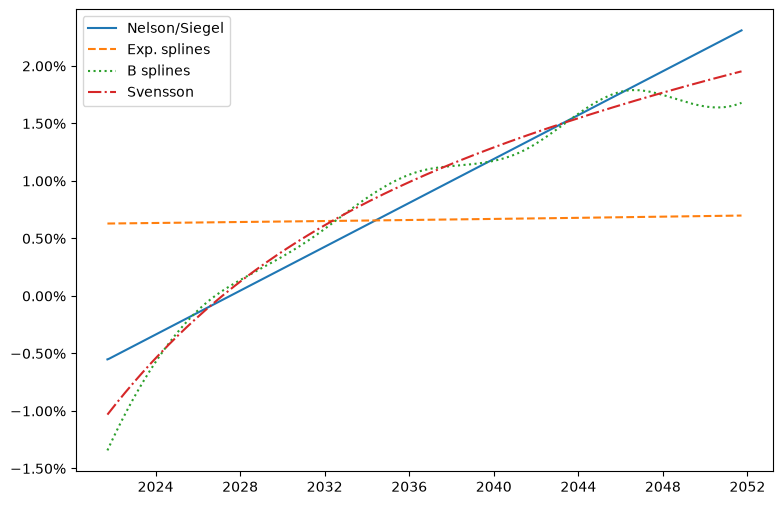

In [11]:
dates = [today +ql.Period(i, ql.Months) for i in range(12 * 30 + 1)]
styles = iter(["-","--",":","-."])

ax = plt.figure(figsize=(9,6)).add_subplot(1, 1, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for tag in curves:
    rates = [
        curves[tag].zeroRate(d, day_count, ql.Continuous).rate()
        for d in dates
    ]
    ax.plot(
        [d.to_date() for d in dates],
        rates,
        next(styles),
        label=tag
    )
ax.legend(loc="best")


The curve are a diverse bunch, to say the least: Nelson-Siegel and Svensson look sensible; exponential splines are almost flat and, compared to the others, look like the fit failed and we got some best-effort result; and cubic B splines are too wavy for my tastes. How can we get a better sense of their quality?

<h2>Plotting the prices</h2>

With more visualization, of course. The quoted prices can be read from the data; they’re the last column. The bond prices implied by any of the curves are also not hard to get—do you remember we created a discount engine and set it to each bond? This pays off now: we can link its discount handle to the desired curve and ask each bond for its price; that’s what the prices function does. The error function calls the latter and returns the difference between calculated and quoted prices.

In [12]:
quoted_prices = [row[-1] for row in data]

def prices(tag):
    discount_curve.linkTo(curves[tag])
    return [b.cleanPrice() for b in bonds]

def errors(tag):
    return [q - p for p, q in zip(prices(tag), quoted_prices)]

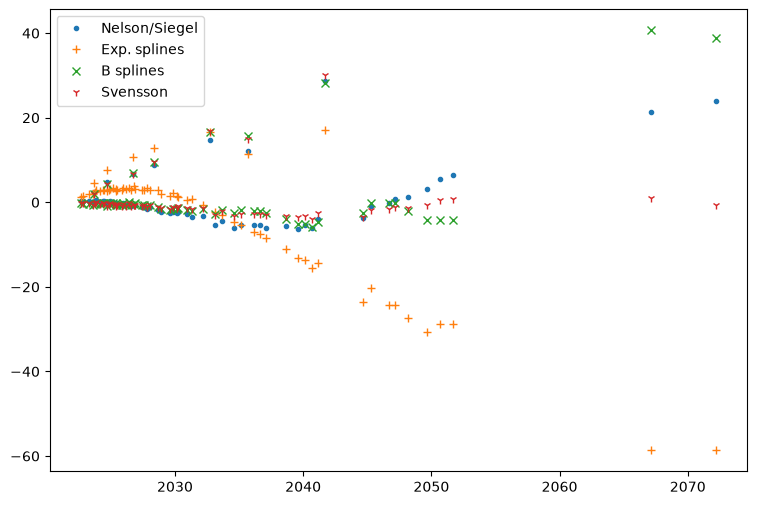

In [13]:
ax = plt.figure(figsize=(9, 6)).add_subplot(1, 1, 1)
maturities = [r[1].to_date() for r in data]
markers = iter([".", "+", "x", "1"])
for tag in curves:
    ax.plot(
        maturities,
        errors(tag),
        next(markers),
        label=tag,
    )
ax.legend(loc="best");

If we restrict ourselves to just one curve (let’s single out Svensson here as the best candidate) we can visualize the calibration errors in yet another way; that’s what the next plot does. Instead of the errors, it plots both quoted and calculated prices against maturities. The figure shows a fit which is not great overall, with noticeable errors for most bonds and a few much larger errors that don’t seem to follow any particular pattern.

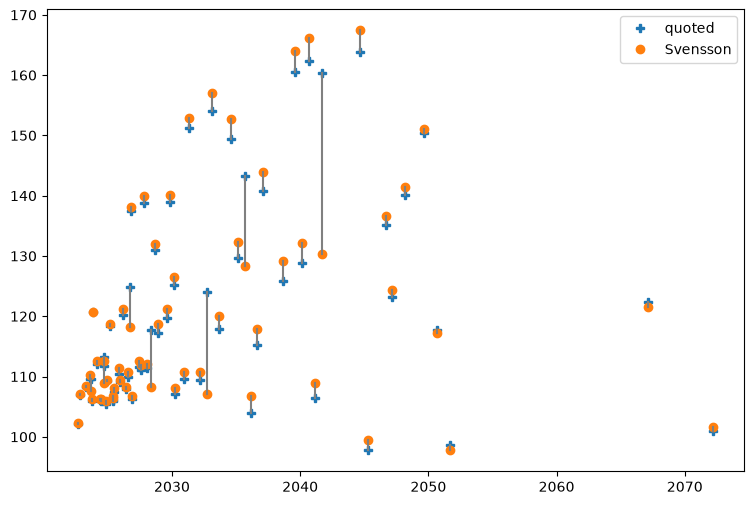

In [14]:
ax = plt.figure(figsize=(9,6)).add_subplot(1, 1, 1)

ps = prices("Svensson")
qs= quoted_prices
ax.plot(maturities, qs, "P", label="quoted")
ax.plot(maturities, ps, "o", label="Svensson")
ax.legend(loc="best")

for m, p, q in zip(maturities, ps, qs):
    ax.plot([m, m], [p, q], "-", color="grey")

<h2>Another point of view</h2>

The yield corresponding to a quoted price can be calculated by passing it to the bondYield method of the corresponding bond; and after linking the desired discount curve, calling the same method without a target price will return the yield corresponding to the calculated price.

The result was enlightening. Most of the yields were on some kind of curve, but we had a few obvious outliers and they were pulling the fit away from the rest of the bonds.

In [15]:
quoted_yields = [
    b.bondYield(
        ql.BondPrice(p, ql.BondPrice.Clean),
        day_count,
        ql.Compounded,
        ql.Annual
    )
    for b, p in zip(bonds, quoted_prices)
]

def yields(tag):
    discount_curve.linkTo(curves[tag])
    return [
        b.bondYield(day_count, ql.Compounded, ql.Annual) for b in bonds
    ]



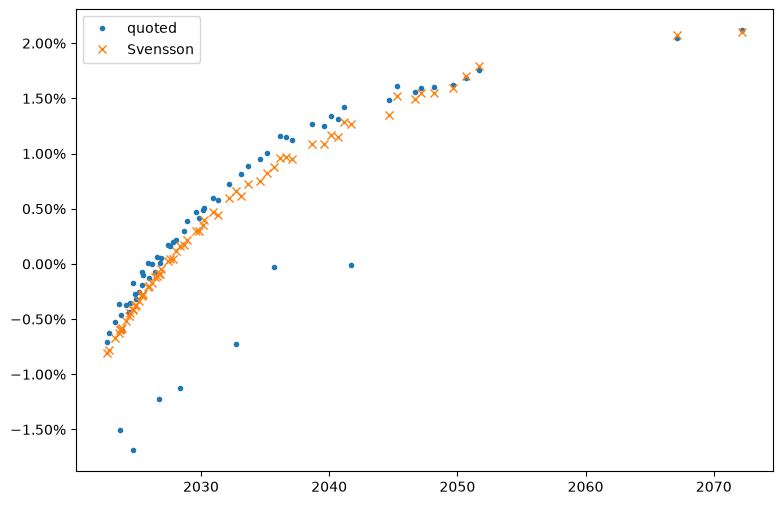

In [16]:
ax = plt.figure(figsize=(9,6)).add_subplot(1, 1, 1)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ys = yields("Svensson")
qys = quoted_yields
ax.plot(maturities, qys, ".", label="quoted")
ax.plot(maturities, ys, "x", label="Svensson")
ax.legend(loc="best")

<h2>Removing the outliers</h2>

Fortunately, it’s also relatively easy to improve the fit. Given the yields we calculated, we can filter out the helpers whose calculated yield differs by more than 50 basis points from the yield implied by the quoted price. We then create a new curve, passing only the filtered helpers.

In [17]:
ys = yields("Svensson")
qys = quoted_yields

filtered_helpers = [
    h for h, y1, y2 in zip (helpers, ys, qys) if abs(y1 -y2) < 0.005
]

In [19]:
curves["Svensson (new)"] = ql.FittedBondDiscountCurve(
    today,
    filtered_helpers,
    day_count,
    ql.SvenssonFitting(),
    tolerence,
    max_iterations
)

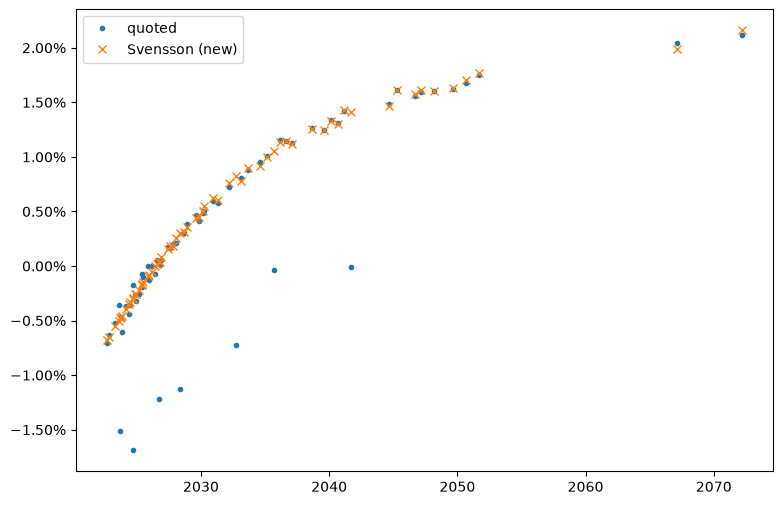

In [21]:
ax = plt.figure(figsize=(9,6)).add_subplot(1, 1, 1)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ys = yields("Svensson")
ys2 = yields("Svensson (new)")
qys = quoted_yields
ax.plot(maturities, qys, ".", label="quoted")
ax.plot(maturities, ys2, "x", label="Svensson (new)")
ax.legend(loc="best")


…and prices; both show a definite improvement of the quality of the fit. The mood of everyone involved in that training was also markedly improved.

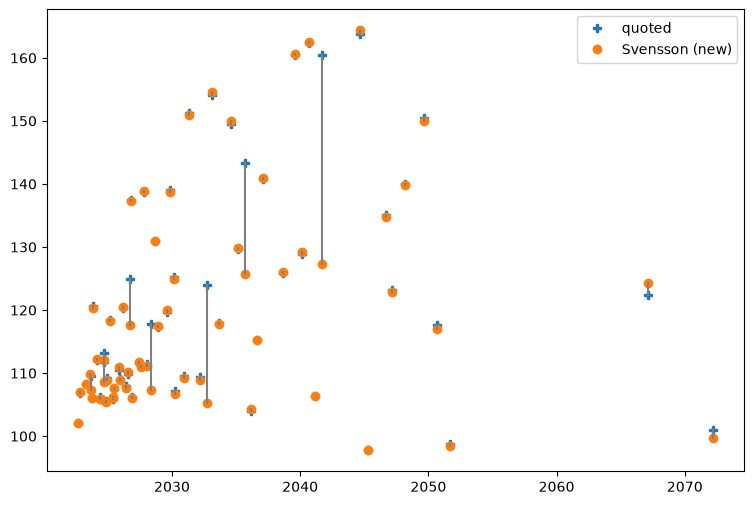

In [22]:
ax = plt.figure(figsize=(9,6)).add_subplot(1, 1, 1)

ps = prices("Svensson (new)")
qs = quoted_prices
ax.plot(maturities, qs, "P", label="quoted")
ax.plot(maturities, ps, "o", label="Svensson (new)")
ax.legend(loc="best")
for m, p, q in zip(maturities, ps, qs):
    ax.plot([m,m],[p,q],"-",color="grey")